# 06 — Filtering YouTube Videos

**Pipeline step:** Sections 3.1.2–3.1.3 of the paper — domain-based filtering of the raw URL
dataset (justifying Table 1) and extraction of the YouTube subset.

**Purpose.**
1. Inspect raw domains to justify filtering down to major social platforms (Table 1).
2. Count links per platform, matching the domain patterns reported in the paper's Table 1.
3. Extract all YouTube URLs into their own file (`youtube_links.jsonl`).
4. Reproduce the YouTube-only version of the monthly occurrence plot
   (`contagem_ocorrencias_yt.png`).

**Input:**
- `../data/telegram_2024/urls.json.gz` — all extracted URLs (line-delimited JSON), same source
  used in `05_Links.ipynb`.

**Output:**
- `../data/telegram_2024/youtube_links.jsonl` — YouTube-only subset of the URL dataset.
- `../reports/Figures/contagem_ocorrencias_yt.png`.

**Next step:** `07_Extracting_infos_yt.ipynb`, which enriches each video via the YouTube Data API.

> ⚠️ **Documentation gap found here — needs your input.** Section 3.1.3 of the paper reports a
> breakdown of YouTube URLs by content type (video: 1,602,384; short: 161,247; live: 137,615;
> playlist: 5,686; channel: 4,498; clip: 907; other: 8,455). In the original notebook these
> numbers appeared as a hand-typed markdown note, with no code that computes them. I did not
> reconstruct this logic myself — a URL-classification regex I guessed might not reproduce
> these exact published numbers, which would silently make the paper's own reported figures
> non-reproducible. See the flagged cell near the bottom of this notebook: please paste in
> (or point me to) the original classification code so I can turn it into real, tested code
> instead of a static comment.


In [ ]:
import gzip
import json
from collections import Counter
from pathlib import Path
from urllib.parse import urlparse

import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
#contagem_links = Counter()

In [ ]:
URLS_JSONL_GZ_PATH = "../data/telegram_2024/urls.json.gz"
YOUTUBE_LINKS_PATH = "../data/telegram_2024/youtube_links.jsonl"
FIGURES_DIR = Path("../reports/Figures")

# Domain patterns per platform — matches Table 1 in the paper.
PLATFORM_DOMAINS = {
    "x": ["twitter.com", "x.com", "t.co"],
    "youtube": ["youtube.com", "youtu.be"],
    "instagram": ["instagram.com"],
    "rumble": ["rumble.com"],
    "tiktok": ["tiktok.com"],
    "facebook": ["facebook.com", "fb.com", "fb.watch"],
    "vk": ["vk.com", "vkontakte.ru"],
    "truthsocial": ["truthsocial.com"],
}

In [ ]:
#file_path = 'telegram_2024/urls.json.gz'

## 1. Sanity check: total raw URL records

In [ ]:
"""with gzip.open(file_path, "rt") as f:
    count = 0
    for line in f:
        count+=1

print(f"Total de links: {count}")"""

with gzip.open(URLS_JSONL_GZ_PATH, "rt") as f:
    total_records = sum(1 for _ in f)

print(f"Total raw URL records: {total_records}")

Total de links: 13487251


## 2. Raw domain exploration

Before applying the platform filter, we look at *all* domains present in the raw data — this
manual inspection is what motivated restricting the analysis to major social platforms
(Section 3.1.2), since many domains fall outside the scope of the study (crypto, NFTs,
promotional pages, etc.).

In [ ]:
"""with gzip.open(file_path, "rt") as f:
    count = 0
    for line in f:
        print(line)
        break"""

{"url":"HTTPS://AP211.BONGVIPVN1.COM","occurrences":[{"id":304692,"folder":"channel_1975967342","date":"2024-08-15"},{"id":304736,"folder":"channel_1975967342","date":"2024-08-15"},{"id":304795,"folder":"channel_1975967342","date":"2024-08-15"},{"id":304864,"folder":"channel_1975967342","date":"2024-08-15"},{"id":310804,"folder":"channel_1975967342","date":"2024-08-18"},{"id":106369,"folder":"channel_1954168752","date":"2024-08-15"},{"id":106408,"folder":"channel_1954168752","date":"2024-08-15"},{"id":106445,"folder":"channel_1954168752","date":"2024-08-15"},{"id":110655,"folder":"channel_1954168752","date":"2024-08-18"},{"id":111473,"folder":"channel_1954168752","date":"2024-08-19"},{"id":111540,"folder":"channel_1954168752","date":"2024-08-19"},{"id":111905,"folder":"channel_1954168752","date":"2024-08-19"},{"id":112545,"folder":"channel_1954168752","date":"2024-08-20"},{"id":373590,"folder":"channel_1658915822","date":"2024-08-15"},{"id":373665,"folder":"channel_1658915822","date":"

In [ ]:
domain_counts = Counter()

with gzip.open(URLS_JSONL_GZ_PATH, "rt", encoding="utf-8") as f:
    for line in tqdm(f, desc="Extracting domains", total=total_records):
        if not line.strip():
            continue
        try:
            item = json.loads(line)
        except json.JSONDecodeError:
            continue

        full_url = item.get("url")
        if not full_url:
            continue

        domain = urlparse(full_url.lower()).netloc
        if domain.startswith("www."):
            domain = domain[4:]
        if domain:
            domain_counts[domain] += 1

print("Top 30 domains overall:")
for domain, count in domain_counts.most_common(30):
    print(f"{domain:<30} | {count} occurrences")

In [ ]:
"""import gzip
import json
from collections import Counter
from urllib.parse import urlparse
from tqdm.notebook import tqdm # Use tqdm.auto if not in a notebook

# --- Configure o caminho do seu arquivo aqui ---
file_path = "telegram_2024/urls.json.gz" 

# O Counter é um dicionário especializado para contagem
domain_counter = Counter()

print(f"Iniciando a análise do arquivo: {file_path}")

# Abre o arquivo .gz para leitura em modo texto
with gzip.open(file_path, "rt", encoding="utf-8") as f:
    # O tqdm cria uma barra de progresso, útil para arquivos grandes
    for line in tqdm(f, desc="Processando URLs"):
        # Ignora linhas em branco que podem causar erros
        if not line.strip():
            continue

        try:
            # Carrega a linha como um objeto JSON
            item = json.loads(line)
            
            # Pega a URL do objeto
            full_url = item.get('url')

            if full_url:
                # --- LÓGICA PRINCIPAL ---
                # 1. Analisa a URL para quebrar em partes (protocolo, domínio, caminho, etc.)
                parsed_url = urlparse(full_url.lower()) # .lower() para unificar domínios (Ex: YouTube.com e youtube.com)
                
                # 2. A propriedade 'netloc' contém o domínio. Ex: 'www.youtube.com'
                domain = parsed_url.netloc
                
                # 3. (Opcional) Remove o 'www.' para agrupar 'www.google.com' e 'google.com' juntos
                if domain.startswith('www.'):
                    domain = domain[4:]
                
                # 4. Adiciona o domínio ao contador
                if domain: # Garante que não adicionamos domínios vazios
                    domain_counter[domain] += 1
        
        except json.JSONDecodeError:
            # Se uma linha não for um JSON válido, ela é ignorada
            # print(f"Aviso: Linha com JSON inválido foi ignorada.")
            continue
        except Exception as e:
            # Captura outros erros inesperados
            # print(f"Ocorreu um erro: {e}")
            continue

print("\n--- Análise Concluída! ---")

# Mostra os 30 domínios mais comuns
print("\nOs 30 domínios mais comuns são:")
for domain, count in domain_counter.most_common(30):
    print(f"{domain:<30} | {count} ocorrências")"""

Iniciando a análise do arquivo: telegram_2024/urls.json.gz


Processando URLs: 0it [00:00, ?it/s]

KeyboardInterrupt: 

In [ ]:
with gzip.open(file_path, "rt", encoding="utf-8") as f:  # "rt" = read text
    for line in tqdm(f, desc="Processando links"):
        try:
            data = json.loads(line)
            url = data.get("url", "").lower().strip()
            ocorrencias = data.get("occurrences", [])
            contagem_links[url] += len(ocorrencias)
        except json.JSONDecodeError:
            continue

# Top 10 links mais frequentes
top10 = contagem_links.most_common(10)

print("=== Top 10 links mais frequentes ===")
for url, qtd in top10:
    print(f"{url}: {qtd} vezes")


## Analisando urls de redes sociais

In [ ]:
import gzip
import json
from tqdm import tqdm

# Padrões de domínio para cada rede social
dominios = {
    "x": ["twitter.com", "x.com", "t.co"],
    "instagram": ["instagram.com"],
    "facebook": ["facebook.com", "fb.com", "fb.watch"],
    "tiktok": ["tiktok.com"],
    "vk": ["vk.com", "vkontakte.ru"],
    "truthsocial": ["truthsocial.com"],
    "rumble": ["rumble.com"],
    "youtube": ["youtube.com", "youtu.be"],
}

# Contadores
contadores = {rede: 0 for rede in dominios.keys()}

with gzip.open(file_path, "rt") as f:
    for line in tqdm(f, desc="Processando linhas"):
        try:
            data = json.loads(line)
            url = data.get("url", "").lower()

            for rede, pads in dominios.items():
                if any(pad in url for pad in pads):
                    contadores[rede] += 1
                    break  # já achou a rede, não precisa testar as outras

        except json.JSONDecodeError:
            continue

# Resultado final
print("\n=== Quantidade de links por rede social ===")
for rede, qtd in contadores.items():
    print(f"{rede}: {qtd}")


In [ ]:
soma = sum(contadores.values())
print(f"Total de links: {soma}")

## Extraindo links do youtube

In [2]:
import gzip
import json
from tqdm import tqdm

with gzip.open(file_path, "rt") as f, open("youtube_links.jsonl", "w") as out:
    count = 0
    limit = 0
    for line in tqdm(f, desc="Processando linhas"):
        try:
            data = json.loads(line)
            url = data.get("url", "").lower()
            if "youtube.com" in url or "youtu.be" in url:
                out.write(json.dumps(data) + "\n")
                count += 1
                limit += 1
            if limit == 50000:
                print(f"Foram extraídos {count} links!")
                limit = 0
        except json.JSONDecodeError:
            print("Erro em uma linha!")
            continue


Processando linhas: 395232it [00:34, 41688.76it/s]

Foram extraídos 50000 links!


Processando linhas: 731349it [01:06, 40562.15it/s]

Foram extraídos 100000 links!


Processando linhas: 1076190it [01:43, 18228.12it/s]

...

Processando linhas: 13016120it [21:17, 34688.18it/s]

Foram extraídos 1850000 links!


Processando linhas: 13353407it [21:52, 32425.95it/s]

Foram extraídos 1900000 links!


Processando linhas: 13487251it [22:07, 10163.39it/s]


## Analisando o tipo de conteúdo do youtube

Quantidade de cada tipo de link no YouTube\
video: 1602384\
short: 161247\
live: 137615\
playlist: 5686\
canal: 4498\
clip: 907\
outro: 8455\
\
TOTAL: 1920792

___
### Occuerrence of sharing links

In [1]:
file_path = "data/youtube_links.jsonl"

In [2]:
import pandas as pd
import json

# Carrega a lista de dicionários do arquivo (como você já fez)
data_list = []
try:
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                data_list.append(json.loads(line))
except FileNotFoundError:
    print(f"ERRO: O arquivo '{file_path}' não foi encontrado.")
    exit()

urls = pd.json_normalize(
    data_list,
    record_path='occurrences', 
    meta=['url']             
)

display(urls)

,id,folder,date,url
0,12771,channel_1205583420,2024-04-06,http://www.youtube.com/watch?v=0BskDtKkX6Q
1,88757,channel_1181961026,2024-10-04,http://www.youtube.com/watch?v=1L2V9Ml9Hi0
2,744,channel_1639057388,2023-12-23,http://www.youtube.com/watch?v=2EMyoELeAC0
3,274202,channel_1153527121,2024-04-07,http://www.youtube.com/watch?v=6PmrsXPrP0I
4,533712,channel_1828686465,2024-01-24,http://www.youtube.com/watch?v=OKN8dFO_ZLA
...,...,...,...,...
9126006,11648,channel_1432345705,2023-12-16,www.youtube.com/watch?v=lBX7yZ64xew
9126007,3236,channel_1472354886,2023-12-17,www.youtube.com/watch?v=lBX7yZ64xew
9126008,18143,channel_1328921622,2023-12-19,www.youtube.com/watch?v=lBX7yZ64xew
9126009,18143,channel_1328921622,2023-12-19,www.youtube.com/watch?v=lBX7yZ64xew


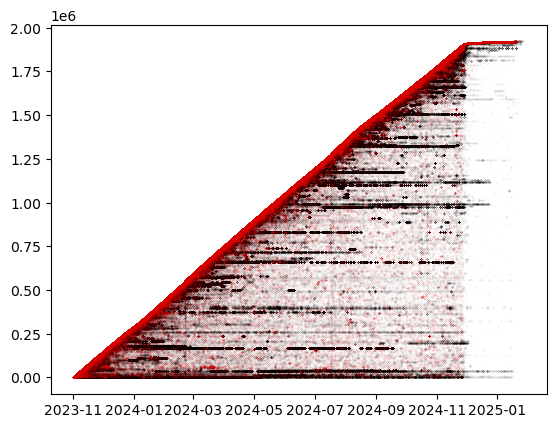

In [4]:
import matplotlib.pyplot as plt

url='url' #PUT HERE THE NAME OF THE COLUMN 
chat_id='folder' #PUT HERE THE NAME OF THE COLUMN 
timestamp='date' #PUT HERE THE NAME OF THE COLUMN 
urls[timestamp] = pd.to_datetime(urls[timestamp])

urls=urls.sort_values(timestamp)
unique_url=urls[url].unique()
mapper=dict(zip(unique_url,range(len(unique_url))))

urls['url_id']=urls[url].map(mapper)
urls['duplicated']=urls.duplicated(subset=['folder','url_id'])


plt.scatter(urls[urls['duplicated']][timestamp],urls[urls['duplicated']]['url_id'],marker='.',s=0.1,alpha=0.1,c='k')

plt.scatter(urls[~urls['duplicated']][timestamp],urls[~urls['duplicated']]['url_id'],marker='.',s=0.1,alpha=0.1,c='r')

In [2]:
import json
import gzip
from tqdm import tqdm
import matplotlib.pyplot as plt
from collections import Counter

counter = Counter()

with open(file_path, "rt", encoding="utf-8") as f:
    for line in tqdm(f, desc="Processando linhas"):
        try:
            if line.strip():
                item = json.loads(line)

                if "occurrences" in item and isinstance(item["occurrences"], list):
                    for occurrence in item["occurrences"]:
                        if "date" in occurrence:
                            date = occurrence["date"][:7]  # YYYY-MM
                            counter[date] += 1
        except json.JSONDecodeError:
            continue

Processando linhas: 1920792it [00:33, 57088.88it/s]


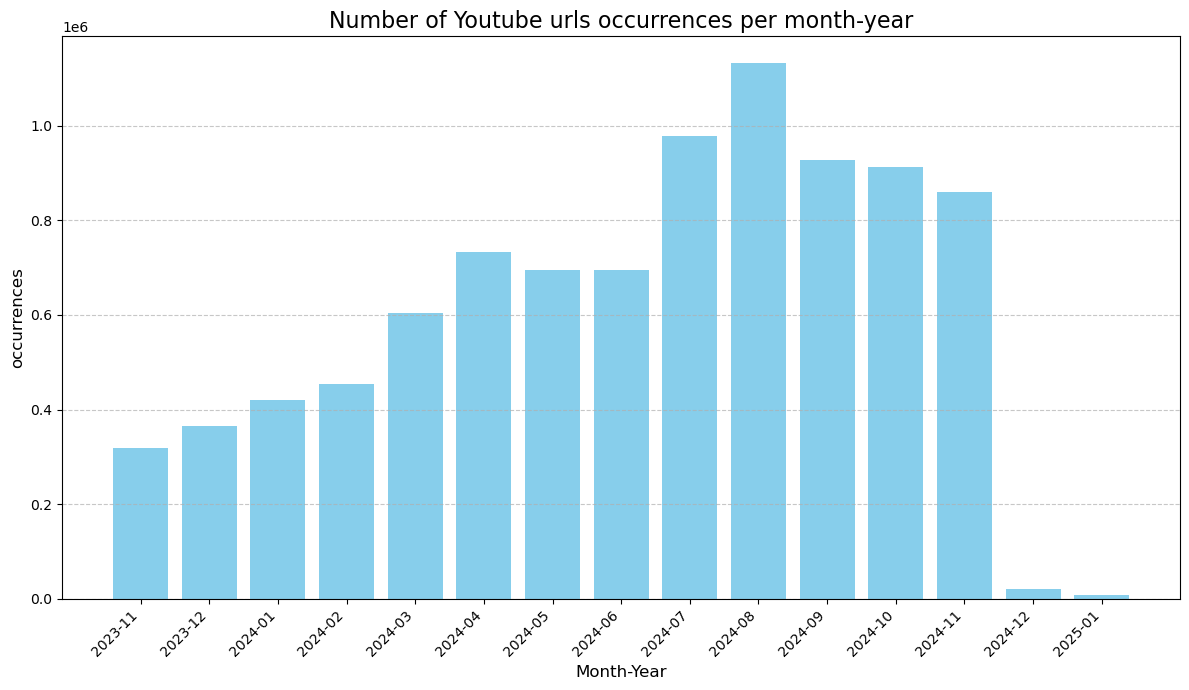

In [3]:
date_ordered = sorted(counter.keys())
values_ordered = [counter[date] for date in date_ordered]

plt.figure(figsize=(12,7))
plt.bar(date_ordered, values_ordered, color="skyblue")

plt.title("Number of Youtube urls occurrences per month-year", fontsize=16)
plt.ylabel("occurrences",fontsize=12)
plt.xlabel("Month-Year",fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(axis='y',linestyle='--',alpha=0.7)
plt.tight_layout()
plt.savefig('contagem_ocorrencias_yt.png')

